## Instacart Market Processing

### 1. Objective
Build a data processing pipeline to clean, transform, and analyze Instacart order data in order to understand consumer behavior and identify insights that help improve customer satisfaction and encourage repeat purchases.

### 2. Import Libraries

In [ ]:
# Data Ingestion
from pathlib import Path

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Read Data

#### 3.1 Orders

In [ ]:
# Load your dataset and verify that all columns and rows are displayed correctly

import pandas as pd

# Source file
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\orders\orders.csv")

# Explore data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 198.9 MB
None


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


#### 3.2 Products

In [3]:
import pandas as pd

# Source file
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\products\products.csv")

# Explore data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   aisle_id       49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 3.0 MB
None


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


#### 3.3 Order Products
Order Products Prior + Order Products train

In [7]:
import pandas as pd

# Paths
train_path = r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\order_products\order_products__train.csv"
prior_path = r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\order_products\order_products__prior.csv"

# Read files
df_train = pd.read_csv(train_path)
df_prior = pd.read_csv(prior_path)

# Combine datasets
df = pd.concat([df_train, df_prior], ignore_index=True)

# Explore
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 1.0 GB
None
   order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0
3         1       49683                  4          0
4         1       43633                  5          1


#### 3.4 Departments

In [5]:
import pandas as pd

# Source file
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\departments\departments.csv")

# Explore data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 638.0 bytes
None


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


#### 3.5 Aisles

In [1]:
import pandas as pd

# Source file
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\raw\aisles\aisles.csv")

# Explore data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.2 KB
None


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


### 4. Transform Data

In [9]:
from pathlib import Path
import pandas as pd

# Base Path
BASE_PATH = Path(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market")

# order_products files (10)
files_order_products = list((BASE_PATH / "data/processed/order_products").glob("*.parquet"))
order_products = pd.concat(
    [pd.read_parquet(f) for f in files_order_products],
    ignore_index=True
)
print(f"Order products: {len(order_products)} filas combinadas.")

# orders files (2)
files_orders = list((BASE_PATH / "data/processed/orders").glob("*.parquet"))
orders = pd.concat(
    [pd.read_parquet(f) for f in files_orders],
    ignore_index=True
)
print(f"Orders: {len(orders)} filas combinadas.")

# individuals files
products = pd.read_parquet(BASE_PATH / "data/processed/products/products.parquet")
aisles = pd.read_parquet(BASE_PATH / "data/processed/aisles/aisles.parquet")
departments = pd.read_parquet(BASE_PATH / "data/processed/departments/departments.parquet")

# Quick verification
print("Shapes:")
print("order_products:", order_products.shape)
print("orders:", orders.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

Order products: 33819106 filas combinadas.
Orders: 3421083 filas combinadas.
Shapes:
order_products: (33819106, 4)
orders: (3421083, 7)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


In [ ]:
# Join files to a single file. Order Products should be the main file.
# Look for connections fields to link them and join both files. 

import duckdb

con = duckdb.connect()

con.register("order_products", order_products)
con.register("orders", orders)
con.register("products", products)
con.register("aisles", aisles)
con.register("departments", departments)

query = """
SELECT
    p.product_id,
    p.product_name,
    a.aisle,
    d.department,
    o.order_id,
    o.user_id,
    o.order_number,
    o.order_dow,
    o.order_hour_of_day
FROM order_products op
JOIN products p 
    ON op.product_id = p.product_id
JOIN orders o 
    ON op.order_id = o.order_id
JOIN aisles a 
    ON p.aisle_id = a.aisle_id
JOIN departments d 
    ON p.department_id = d.department_id
"""
df_joined = con.execute(query).fetchdf()

print(df_joined.head())

   product_id           product_name               aisle  department  \
0       33120     Organic Egg Whites                eggs  dairy eggs   
1       28985  Michigan Organic Kale    fresh vegetables     produce   
2        9327          Garlic Powder   spices seasonings      pantry   
3       45918         Coconut Butter       oils vinegars      pantry   
4       30035      Natural Sweetener  baking ingredients      pantry   

   order_id  user_id  order_number  order_hour_of_day  
0         2   202279             3                  9  
1         2   202279             3                  9  
2         2   202279             3                  9  
3         2   202279             3                  9  
4         2   202279             3                  9  


In [ ]:
# Save in Parquet format
df_joined.to_parquet(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\cleaned\instacart_joined.parquet", index=False)

### 5. Validate Data

#### 5.1 Basic Validation

In [28]:
# Null Values
df_joined.isnull().sum()

product_id           0
product_name         0
aisle                0
department           0
order_id             0
user_id              0
order_number         0
order_hour_of_day    0
dtype: int64

In [ ]:
# Dtypes
df_joined.dtypes

product_id           int32
product_name           str
aisle                  str
department             str
order_id             int32
user_id              int32
order_number         int32
order_hour_of_day    int32
dtype: object

In [ ]:
# Duplicated values
df_joined.duplicated().sum()

np.int64(0)

In [ ]:
# Hours range
df_joined['order_hour_of_day'].min(), df_joined['order_hour_of_day'].max()

(np.int32(0), np.int32(23))

#### 5.2 Quick Cross Validation 

In [ ]:
# product_id associated to a single product
df_joined.groupby('product_id')['product_name'].nunique()

product_id
1        1
2        1
3        1
4        1
5        1
        ..
49684    1
49685    1
49686    1
49687    1
49688    1
Name: product_name, Length: 49685, dtype: int64

In [ ]:
# Total orders by user
df_joined.groupby('user_id')['order_number'].max()

user_id
1         11
2         15
3         12
4          5
5          5
          ..
206205     4
206206    67
206207    16
206208    49
206209    14
Name: order_number, Length: 206209, dtype: int32

In [ ]:
# One name and category for product_id
product_check = df_joined.groupby('product_id').agg({
    'product_name':'nunique',
    'aisle':'nunique',
    'department':'nunique'
}).reset_index()

product_check[(product_check['product_name']>1) |
              (product_check['aisle']>1) |
              (product_check['department']>1)]

,product_id,product_name,aisle,department


In [ ]:
# Duplicate product_name with different product_id
name_duplicates = df_joined.groupby('product_name')['product_id'].nunique()
name_duplicates[name_duplicates > 1]

Series([], Name: product_id, dtype: int64)

In [ ]:
# Repeated products in an order
df_joined[df_joined.duplicated(subset=['order_id','product_id'], keep=False)]

,product_id,product_name,aisle,department,order_id,user_id,order_number,order_hour_of_day


In [ ]:
# Orders without products
df_joined.groupby('order_id')['product_id'].count().loc[lambda x: x==0]

Series([], Name: product_id, dtype: int64)

In [ ]:
# Each order_id associated to a single user_id
df_joined.groupby('order_id')['user_id'].nunique().loc[lambda x: x>1]

Series([], Name: user_id, dtype: int64)

### 6. Queries with DuckDB

In [7]:
import duckdb

# Connect and consult Parquet
df = duckdb.read_parquet(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market\data\cleaned\instacart_joined.parquet")

# Total orders by deparment
result = duckdb.query("""
    SELECT department, COUNT(DISTINCT order_id) as total_orders
    from df
    Group by department
    ORDER BY total_orders DESC
""").df()


print(result)

         department  total_orders
0           produce       2506247
1        dairy eggs       2264738
2         beverages       1518833
3            snacks       1448749
4            frozen       1232089
5            pantry       1165491
6            bakery        917980
7              deli        802581
8      canned goods        710721
9   dry goods pasta        623738
10     meat seafood        599017
11        breakfast        547067
12        household        492427
13    personal care        333463
14    international        231253
15           babies        184074
16          alcohol         87794
17          missing         66410
18             pets         62011
19            other         36781
20             bulk         35125


### 7. Generate visualizations

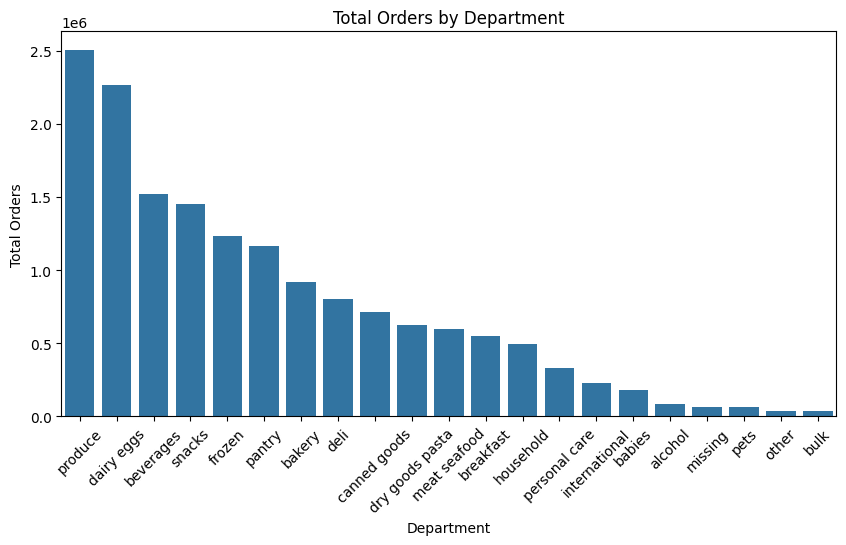

In [ ]:
# Total Orders by Department
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=result, x="department", y="total_orders")

plt.xlabel("Department")
plt.ylabel("Total Orders")
plt.title("Total Orders by Department")

plt.xticks(rotation=45) 
plt.show()
